In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

In [2]:
# ─────────────────────────────────────────────
#  1. ENVIRONMENT SETUP
# ─────────────────────────────────────────────

# Grid dimensions
GRID_ROWS = 15
GRID_COLS = 15

# Fixed random seed
random.seed(42)
np.random.seed(42)

# Depot
DEPOT = (1, 1)

# Delivery points
DELIVERY_POINTS = {
    "P1": (2, 10),
    "P2": (7, 3),
    "P3": (13, 6),
    "P4": (5, 13),
    "P5": (11, 11),
    "P6": (9, 1),
}

# Obstacles
OBSTACLES = {
    (3, 2), (3, 3), (3, 4), (3, 5),
    (6, 6), (7, 6), (8, 6), (9, 6), (10, 6),
    (2, 7), (3, 7), (4, 7),
    (11, 2), (11, 3), (11, 4),
    (5, 9), (6, 9), (6, 10), (6, 11),
    (12, 8), (12, 9), (13, 9),
    (1, 12), (2, 12), (2, 13),
    (8, 12), (9, 12), (9, 13),
    (4, 4),
}

POINT_NAMES = list(DELIVERY_POINTS.keys())   # ["P1","P2","P3","P4","P5","P6"]
POINT_COORDS = list(DELIVERY_POINTS.values())  # coordinate list

print("Environment initialized successfully.")
print("Depot:", DEPOT)
print("Delivery Points:", DELIVERY_POINTS)

Environment initialized successfully.
Depot: (1, 1)
Delivery Points: {'P1': (2, 10), 'P2': (7, 3), 'P3': (13, 6), 'P4': (5, 13), 'P5': (11, 11), 'P6': (9, 1)}


In [3]:
# ─────────────────────────────────────────────
#  2. BFS — Shortest Path Cost
# ─────────────────────────────────────────────
def is_valid(r, c):
    """Return True if cell (r,c) is inside the grid and not an obstacle."""
    return 0 <= r < GRID_ROWS and 0 <= c < GRID_COLS and (r, c) not in OBSTACLES


def bfs_cost(start, goal):
    """
    Breadth-First Search from 'start' to 'goal' on the grid.
    Returns the minimum number of steps (cost), or infinity if unreachable.
    Each step moves to an adjacent cell (up/down/left/right).
    """
    if start == goal:
        return 0

    visited = {start}
    queue = deque([(start, 0)])      # (current_position, steps_so_far)

    while queue:
        (r, c), steps = queue.popleft()

        for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:     # 4-directional moves
            nr, nc = r + dr, c + dc

            if (nr, nc) == goal:
                return steps + 1        # goal reached

            if is_valid(nr, nc) and (nr, nc) not in visited:
                visited.add((nr, nc))
                queue.append(((nr, nc), steps + 1))

    return float('inf')                  # goal unreachable


def compute_all_bfs_costs():
    """
    Run BFS once from the Depot to each of the 6 delivery points.
    Returns a dict: {"P1": cost1, "P2": cost2, ...}
    """
    costs = {}

    for name, coord in DELIVERY_POINTS.items():
        cost = bfs_cost(DEPOT, coord)
        costs[name] = cost
        print(f"Depot → {name} {coord} = {cost} steps")

    return costs

In [4]:
bfs_costs = compute_all_bfs_costs()

print("\nTotal Cost:", sum(bfs_costs.values()))

Depot → P1 (2, 10) = 10 steps
Depot → P2 (7, 3) = 8 steps
Depot → P3 (13, 6) = 17 steps
Depot → P4 (5, 13) = 16 steps
Depot → P5 (11, 11) = 20 steps
Depot → P6 (9, 1) = 8 steps

Total Cost: 79


In [5]:
# ─────────────────────────────────────────────
#  3. GENETIC ALGORITHM
# ─────────────────────────────────────────────
POPULATION_SIZE = 60
NUM_GENERATIONS = 150
MUTATION_RATE = 0.15
ELITE_COUNT = 4
CHROMOSOME_LEN = 6

print("GA Parameters Loaded.")

GA Parameters Loaded.


In [6]:
def fitness(chromosome, bfs_costs):
    """
    Fitness Function (minimisation problem converted to maximisation).

    Given a chromosome [b0, b1, b2, b3, b4, b5] where bi ∈ {0, 1}:
      - bi = 0  →  package Pi+1 assigned to Vehicle 1
      - bi = 1  →  package Pi+1 assigned to Vehicle 2

    dist1 = Σ bfs_costs[Pi]  for all i where bi = 0
    dist2 = Σ bfs_costs[Pi]  for all i where bi = 1

    Imbalance = |dist1 − dist2|

    We want Imbalance → 0.  Because GA maximises fitness we use:
        fitness = 1 / (1 + Imbalance)

    Perfect balance  →  Imbalance = 0  →  fitness = 1.0  (maximum)
    Terrible balance →  Imbalance = large  →  fitness ≈ 0
    """
    dist1 = sum(
        bfs_costs[POINT_NAMES[i]]
        for i in range(CHROMOSOME_LEN)
        if chromosome[i] == 0
    )

    dist2 = sum(
        bfs_costs[POINT_NAMES[i]]
        for i in range(CHROMOSOME_LEN)
        if chromosome[i] == 1
    )

    imbalance = abs(dist1 - dist2)

    return 1.0 / (1.0 + imbalance)

In [7]:
def random_chromosome():
    """Generate one random binary chromosome of length 6."""
    return [random.randint(0, 1) for _ in range(CHROMOSOME_LEN)]


def initialise_population():
    """Create the initial population of POPULATION_SIZE random chromosomes."""

    return [random_chromosome() for _ in range(POPULATION_SIZE)]

population = initialise_population()

print("Sample Chromosome:")
print(population[0])

Sample Chromosome:
[0, 0, 1, 0, 0, 0]


In [8]:
def select_parent(population, fitnesses):
    """
    Roulette-wheel (fitness-proportionate) selection.
    Higher fitness → higher chance of being picked as a parent.
    """
    total = sum(fitnesses)

    pick = random.uniform(0, total)

    cumulative = 0

    for chrom, fit in zip(population, fitnesses):

        cumulative += fit

        if cumulative >= pick:
            return chrom

    return population[-1]    # fallback

In [9]:
def single_point_crossover(parent1, parent2):
    """
    Single-Point Crossover:
      1. Pick a random crossover point k in [1, CHROMOSOME_LEN-1].
      2. Child 1 = parent1[0:k] + parent2[k:]
      3. Child 2 = parent2[0:k] + parent1[k:]
    Returns both children.
    """
   # k = random.randint(1, CHROMOSOME_LEN - 1)
    k=3
    child1 = parent1[:k] + parent2[k:]
    child2 = parent2[:k] + parent1[k:]

    return child1, child2


# Example
p1 = [1,0,1,0,0,1]
p2 = [0,1,0,1,1,0]

c1, c2 = single_point_crossover(p1, p2)

print("Parent 1:", p1)
print("Parent 2:", p2)
print("Child 1 :", c1)
print("Child 2 :", c2)

Parent 1: [1, 0, 1, 0, 0, 1]
Parent 2: [0, 1, 0, 1, 1, 0]
Child 1 : [1, 0, 1, 1, 1, 0]
Child 2 : [0, 1, 0, 0, 0, 1]


In [10]:
def mutate(chromosome):
    """
    Bit-flip mutation:
    Each gene is independently flipped (0→1 or 1→0) with probability MUTATION_RATE.
    """
    return [
        1 - gene if random.random() < MUTATION_RATE else gene
        for gene in chromosome
    ]


sample = [1,0,0,1,1,0]

print("Before Mutation:", sample)
print("After Mutation :", mutate(sample))

Before Mutation: [1, 0, 0, 1, 1, 0]
After Mutation : [1, 0, 1, 1, 1, 1]


In [11]:
def run_ga(bfs_costs):
    """
    Main GA loop.
    Returns: best_chromosome, best_fitness_score, history (list of best fitness per gen)
    """
    population = initialise_population()

    history = []      # track best fitness each generation

    for generation in range(NUM_GENERATIONS):
        # Evaluate fitness for every chromosome
        fitnesses = [fitness(c, bfs_costs) for c in population]

        # Record the best fitness this generation
        best_fit = max(fitnesses)
        history.append(best_fit)

        # ── Elitism: carry top ELITE_COUNT chromosomes unchanged ──
        sorted_pop = sorted(
            zip(fitnesses, population),
            key=lambda x: x[0],
            reverse=True
        )

        new_population = [
            chrom for _, chrom in sorted_pop[:ELITE_COUNT]
        ]

        # ── Fill the rest via selection → crossover → mutation ──
        while len(new_population) < POPULATION_SIZE:

            p1 = select_parent(population, fitnesses)
            p2 = select_parent(population, fitnesses)

            c1, c2 = single_point_crossover(p1, p2)

            new_population.append(mutate(c1))

            if len(new_population) < POPULATION_SIZE:
                new_population.append(mutate(c2))

        population = new_population

  # Final evaluation
    fitnesses = [fitness(c, bfs_costs) for c in population]

    best_idx = fitnesses.index(max(fitnesses))

    return population[best_idx], fitnesses[best_idx], history

In [12]:
best_chromosome, best_fit, history = run_ga(bfs_costs)

print("Best Chromosome:", best_chromosome)
print("Best Fitness:", best_fit)

Best Chromosome: [0, 1, 1, 1, 0, 0]
Best Fitness: 0.25


In [13]:
# ─────────────────────────────────────────────
#  4. RESULT ANALYSIS
# ─────────────────────────────────────────────
def decode_solution(chromosome, bfs_costs):
    """
    Decode a chromosome into human-readable vehicle assignments and distances.
    Returns dicts for vehicle1 and vehicle2 assignments and their total distances.
    """
    vehicle1 = {}
    vehicle2 = {}

    for i, gene in enumerate(chromosome):

        name = POINT_NAMES[i]
        cost = bfs_costs[name]

        if gene == 0:
            vehicle1[name] = cost
        else:
            vehicle2[name] = cost

    dist1 = sum(vehicle1.values())
    dist2 = sum(vehicle2.values())

    return vehicle1, vehicle2, dist1, dist2


vehicle1, vehicle2, dist1, dist2 = decode_solution(best_chromosome, bfs_costs)

print("Vehicle 1:", vehicle1)
print("Vehicle 2:", vehicle2)

print("Distance V1:", dist1)
print("Distance V2:", dist2)

print("Imbalance:", abs(dist1 - dist2))

Vehicle 1: {'P1': 10, 'P5': 20, 'P6': 8}
Vehicle 2: {'P2': 8, 'P3': 17, 'P4': 16}
Distance V1: 38
Distance V2: 41
Imbalance: 3


In [ ]:
def plot_grid_assignment(chromosome, bfs_costs):
    """
    Plot 1: Grid map showing:
      - Green obstacles
      - Depot (blue star)
      - Delivery points coloured Green (Vehicle 1) or Orange (Vehicle 2)
      - BFS cost label next to each point
    """
    fig, ax = plt.subplots(figsize=(9, 9))
    fig.patch.set_facecolor("#62836d")
    ax.set_facecolor("#62836d")

    # Draw grid lines
    for r in range(GRID_ROWS + 1):
        ax.axhline(r, color="#578b68", linewidth=0.4)
    for c in range(GRID_COLS + 1):
        ax.axvline(c, color='#578b68', linewidth=0.4)

    # Draw obstacles
    for (r, c) in OBSTACLES:
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color="#86AC93", zorder=2))

    # Decode assignments
    vehicle1, vehicle2, dist1, dist2 = decode_solution(chromosome, bfs_costs)

    # Draw depot
    dr, dc = DEPOT
    ax.plot(dc + 0.5, dr + 0.5, 'b*', markersize=22, zorder=5, label='Depot')
    ax.text(dc + 0.5, dr + 0.9, 'DEPOT', color='#89CFF0',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Draw delivery points
    for i, (name, coord) in enumerate(DELIVERY_POINTS.items()):
        r, c = coord
        color = '#4ade80' if chromosome[i] == 0 else "#edaa73"   # green / orange
        vehicle_label = 'V1' if chromosome[i] == 0 else 'V2'
        cost = bfs_costs[name]

        ax.plot(c + 0.5, r + 0.5, 'o', color=color, markersize=18,
                zorder=5, markeredgecolor='white', markeredgewidth=1.2)
        ax.text(c + 0.5, r + 0.5, name, color='black',
                ha='center', va='center', fontsize=7.5, fontweight='bold', zorder=6)
        ax.text(c + 0.5, r - 0.05, f'{vehicle_label} | {cost}s',
                color=color, ha='center', va='top', fontsize=6.5, zorder=6)

    # Legend
    v1_patch = mpatches.Patch(color='#4ade80', label=f'Vehicle 1  (total: {dist1} steps)')
    v2_patch = mpatches.Patch(color='#edaa73', label=f'Vehicle 2  (total: {dist2} steps)')
    depot_marker = plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='blue',
                               markersize=12, label='Depot', linestyle='None')
    ax.legend(handles=[depot_marker, v1_patch, v2_patch],
              loc='upper right', facecolor="#8cc19d", edgecolor='#89CFF0',
              labelcolor='white', fontsize=9)

    ax.set_xlim(0, GRID_COLS)
    ax.set_ylim(0, GRID_ROWS)
    ax.set_xticks(range(GRID_COLS))
    ax.set_yticks(range(GRID_ROWS))
    ax.tick_params(colors="#65c886", labelsize=7)
    ax.set_title(
        f'Delivery Allocation — Load Balancing Result\n'
        f'Chromosome: {chromosome}   |   Imbalance: {abs(dist1-dist2)} steps',
        color='white', fontsize=12, fontweight='bold', pad=12
    )
    plt.tight_layout()

    plt.grid(True)

    plt.show()

In [15]:
def plot_ga_convergence(history):
    """
    Plot 2: GA fitness convergence curve over generations.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#62836d')
    ax.set_facecolor('#62836d')

    gens = range(1, len(history) + 1)
    ax.plot(gens, history, color='#62836d', linewidth=2, label='Best Fitness')
    ax.fill_between(gens, history, alpha=0.15, color='#62836d')

    ax.axhline(max(history), color='#4ade80', linestyle='--', linewidth=1.2,
               label=f'Max Fitness = {max(history):.4f}')

    ax.set_xlabel('Generation', color='white', fontsize=11)
    ax.set_ylabel('Best Fitness  [1 / (1 + Imbalance)]', color='white', fontsize=11)
    ax.set_title('GA Convergence — Fitness over Generations',
                 color='white', fontsize=13, fontweight='bold')
    ax.tick_params(colors='#aaaacc')
    ax.legend(facecolor="#418156", edgecolor='#62836d', labelcolor='white', fontsize=10)
    ax.spines[:].set_color('#418156')

    plt.tight_layout()

    plt.grid(True)

    plt.show()

In [16]:
def plot_distance_comparison(vehicle1, vehicle2, dist1, dist2, bfs_costs):
    """
    Plot 3: Side-by-side bar chart comparing per-vehicle package distances.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#62836d')
    fig.suptitle('Vehicle Workload Distribution', color='white',
                 fontsize=14, fontweight='bold')

    for ax, assignments, color, label, total in [
        (axes[0], vehicle1, '#4ade80', 'Vehicle 1', dist1),
        (axes[1], vehicle2, '#edaa73', 'Vehicle 2', dist2),
    ]:
        ax.set_facecolor("#3f8857")
        names  = list(assignments.keys())
        values = list(assignments.values())
        bars = ax.bar(names, values, color=color, edgecolor='white',
                      linewidth=0.8, alpha=0.85)

        # Value labels on bars
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', va='bottom', color='white',
                    fontsize=10, fontweight='bold')

        ax.set_title(f'{label}  —  Total: {total} steps',
                     color=color, fontsize=11, fontweight='bold')
        ax.set_ylabel('BFS Path Cost (steps)', color='white', fontsize=9)
        ax.tick_params(colors='#aaaacc')
        ax.spines[:].set_color("#4f9968")
        ax.set_facecolor('#4f9968')

    plt.tight_layout()

    plt.show()

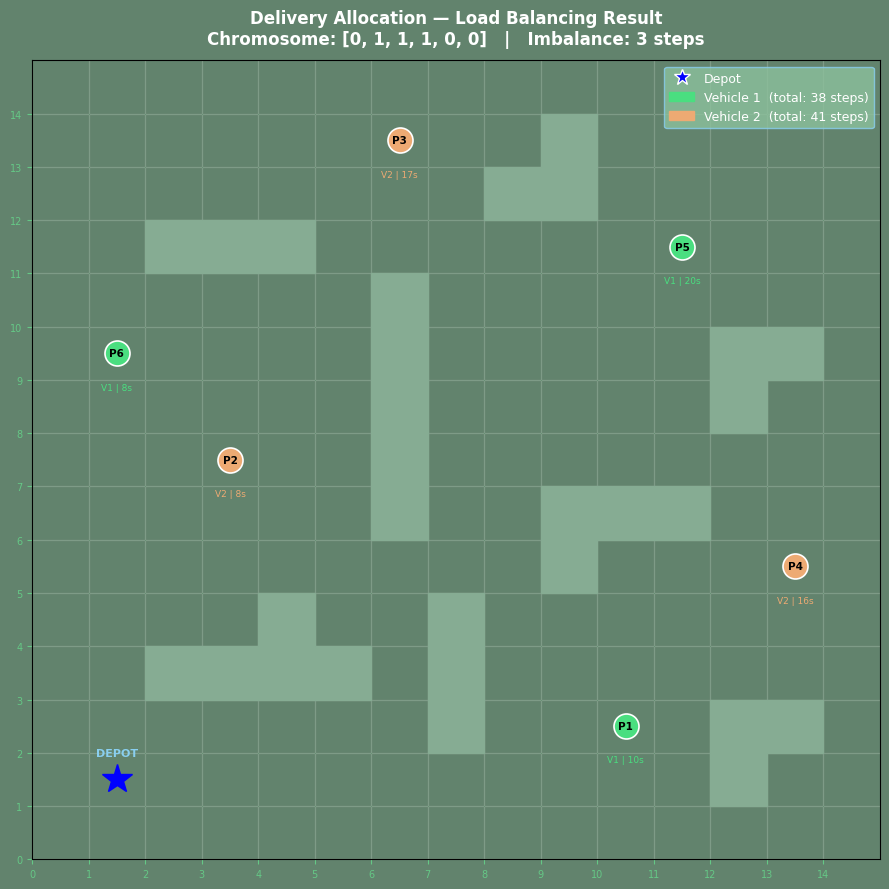

In [17]:
plot_grid_assignment(best_chromosome, bfs_costs)

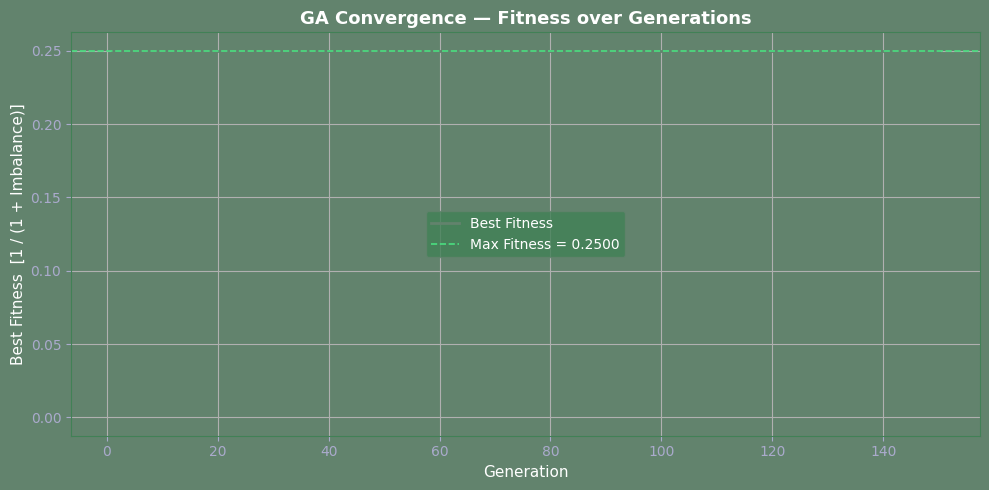

In [18]:
plot_ga_convergence(history)

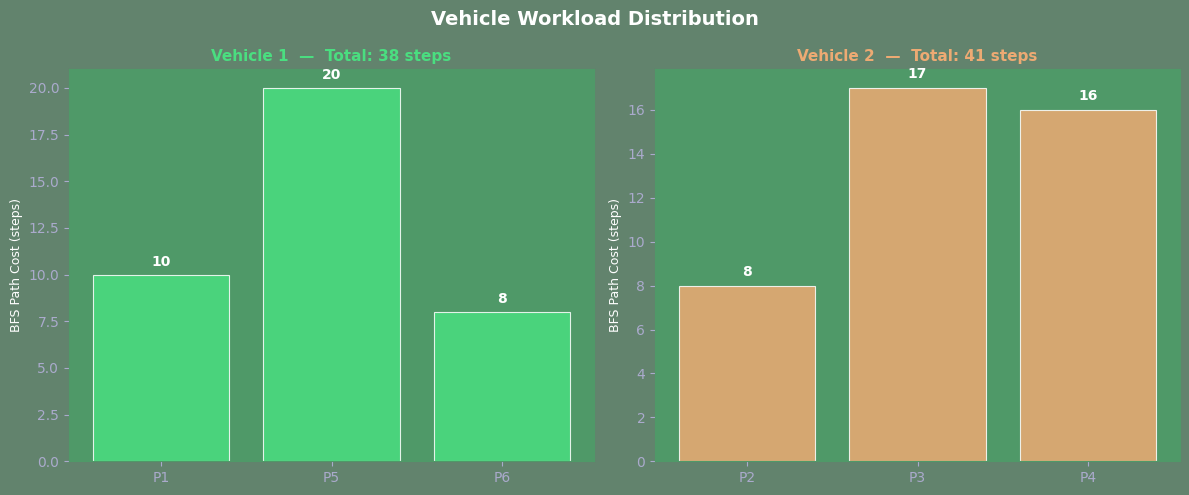

In [19]:
plot_distance_comparison(vehicle1, vehicle2, dist1, dist2, bfs_costs)

In [20]:
print("=" * 50)

print("FINAL RESULT")

print("=" * 50)

print("Best Chromosome:", best_chromosome)

print("Vehicle 1:", list(vehicle1.keys()))
print("Vehicle 2:", list(vehicle2.keys()))

print("Vehicle 1 Distance:", dist1)
print("Vehicle 2 Distance:", dist2)

print("Final Imbalance:", abs(dist1 - dist2))

print("Fitness Score:", best_fit)

FINAL RESULT
Best Chromosome: [0, 1, 1, 1, 0, 0]
Vehicle 1: ['P1', 'P5', 'P6']
Vehicle 2: ['P2', 'P3', 'P4']
Vehicle 1 Distance: 38
Vehicle 2 Distance: 41
Final Imbalance: 3
Fitness Score: 0.25
